In [1]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, MaxPooling2D, Dropout, Flatten, Dense, concatenate

/home/lucifer666/anaconda3/envs/py312/lib/python3.12/site-packages/numpy/_core/getlimits.py:551: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)
2026-08-02 15:36:58.052197: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
data = pd.read_csv('HousesInfo.txt', header=None, sep=' ', names=['bedroom', 'bathroom', 'area', 'zipcode', 'price'])

In [3]:
data.head()

,bedroom,bathroom,area,zipcode,price
0,4,4.0,4053,85255,869500
1,4,3.0,3343,36372,865200
2,3,4.0,3923,85266,889000
3,5,5.0,4022,85262,910000
4,3,4.0,4116,85266,971226


In [4]:
images = []
for i in data.index.values:
    basepath = os.path.sep.join(['data', f'{i + 1}_*'])
    imgPaths = sorted(list(glob.glob(basepath)))
    inputImage = []
    for imgPath in imgPaths:
        image = cv2.resize(cv2.imread(imgPath), (64, 64))
        inputImage.append(image)

    outputImage = np.zeros((128, 128, 3), dtype='uint8')
    outputImage[0:64, 0:64] = inputImage[0]
    outputImage[0:64, 64:128] = inputImage[1]
    outputImage[64:128, 64:128] = inputImage[2]
    outputImage[64:128, 0:64] = inputImage[3]
    images.append(outputImage)


In [5]:
images = np.array(images)
images.shape

(535, 128, 128, 3)

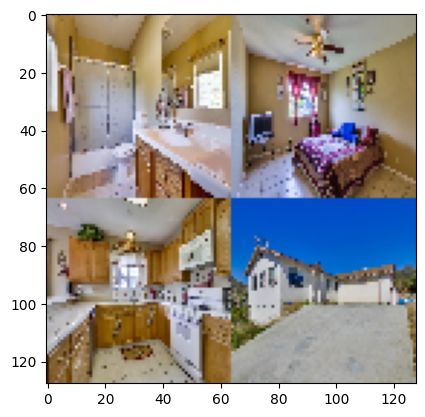

In [6]:
plt.imshow(images[100][..., ::-1])

In [7]:
X_train, X_test, IX_train, IX_test = train_test_split(data, images, test_size=0.2, random_state=42)

In [8]:
maxprice = X_train['price'].max()
y_train = X_train['price'] / maxprice
y_test = X_test['price'] / maxprice

In [9]:
model1 = Sequential([
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(128, 128, 3)),
    BatchNormalization(axis=-1),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(axis=-1),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(axis=-1),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    BatchNormalization(axis=-1),
    Dropout(0.5),
    Dense(16, activation='relu')
])

/home/lucifer666/anaconda3/envs/py312/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-08-02 15:37:48.995853: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [10]:
input_m1 = Input(shape=(128, 128, 3))
m1 = model1(input_m1)

In [11]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,192,656 (8.36 MB)

 Trainable params: 2,192,080 (8.36 MB)

 Non-trainable params: 576 (2.25 KB)

In [12]:
ss = StandardScaler()
XT = ss.fit_transform(X_train[['bedroom', 'bathroom', 'area']])
Xt = ss.transform(X_test[['bedroom', 'bathroom', 'area']])

In [ ]:
lb = LabelBinarizer()
XTz = lb.fit_transform(X_train['zipcode'])
Xtz = lb.transform(X_test['zipcode'])

In [15]:
XT = np.hstack([XT, XTz])
Xt = np.hstack([Xt, Xtz])

In [16]:
XT.shape

(428, 49)

In [17]:
model2 = Sequential([
    Dense(32, activation='relu', input_dim=49),
    Dropout(0.5),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(4, activation='relu')
])

/home/lucifer666/anaconda3/envs/py312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
input_m2 = Input(shape=(49,))
m2 = model2(input_m2)

In [19]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,300 (8.98 KB)

 Trainable params: 2,300 (8.98 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
CombineModel = concatenate([m2, m1])

In [21]:
densef1 = Dense(8, activation='relu')(CombineModel)
densef2 = Dense(1, activation='linear')(densef1)
model = Model(inputs=[input_m2, input_m1], outputs=densef2)

In [22]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 49)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 4)         │      2,300 │ input_layer_3[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 16)        │  2,192,656 │ input_layer_1[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 20)        │          0 │ sequential_1[0][… │
│ (Concatenate)       │                   │            │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 8)         │        168 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │          9 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,195,133 (8.37 MB)

 Trainable params: 2,194,557 (8.37 MB)

 Non-trainable params: 576 (2.25 KB)

In [23]:
model.compile(
    optimizer='adam',
    loss='mean_absolute_error'
)

In [24]:
model.fit([XT, IX_train], y_train, validation_data=([Xt, IX_test], y_test), batch_size=10, epochs=100)

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 28s 400ms/step - loss: 0.3487 - val_loss: 0.5077
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 464ms/step - loss: 0.2568 - val_loss: 0.4770
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 481ms/step - loss: 0.1741 - val_loss: 0.2069
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 471ms/step - loss: 0.1521 - val_loss: 0.1646
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 476ms/step - loss: 0.1431 - val_loss: 0.1350
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 22s 517ms/step - loss: 0.1240 - val_loss: 0.0918
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 489ms/step - loss: 0.1010 - val_loss: 0.1063
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 470ms/step - loss: 0.0974 - val_loss: 0.1082
Epoch 9/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 491ms/step - loss: 0.0982 - val_loss: 0.2286
Epoch 10/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 465ms/step - loss: 0.0992 - val_loss: 0.0939
Epoch 11/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 485ms/step - loss: 0.0842 - val_loss: 0.0777
Epoch 12/100
43/43 ━━━━━━━━━━━

In [25]:
predicts = model.predict([Xt, IX_test]) * maxprice

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 316ms/step


In [26]:
predicts.flatten()

array([ 479851.60221159,  836089.10673857,  138651.28219128,
        515828.37057114,  638746.80261314,  124884.91282985,
        791457.91560411,  773992.29541421,  717825.4673928 ,
        571149.87252653,  524315.28191268,  388043.77067089,
        383601.8370837 ,  486879.66267765,  566260.83442569,
        586688.89300525,  400188.1750077 ,   87082.49680325,
        916699.72860813,  333465.63889086, 1001137.79905438,
         98040.13631865, 1371952.07169652,  598807.32826889,
        861915.02267122,   67166.35630652,  702010.34547389,
       1146298.89503121,  124884.91282985,  472016.79830253,
        262161.54722869,  188453.37407291,  276413.35276514,
        124884.91282985,  191939.3402487 ,  635120.38521469,
        468385.84177196, 1118662.91287541,  559911.59243882,
        585395.24035156,  655920.82720995,  307326.43555105,
        514720.25494277,  254363.9729321 ,  231037.06745803,
        124884.91282985,  868096.53499722,  124884.91282985,
        870627.62489915,

In [27]:
diff = abs(predicts.flatten() - (y_test * maxprice))
diff

117      5148.397788
132    362910.893261
154     31348.717809
245     22171.629429
84      50253.197387
           ...      
322     10859.736046
375     97341.061880
368     44984.912830
534    125182.907805
384     14115.087170
Name: price, Length: 107, dtype: float64

In [28]:
diff.mean()

np.float64(126922.14258535806)

In [29]:
data['price'].mean()

np.float64(589362.8112149533)

In [31]:
from sklearn.metrics import r2_score, mean_absolute_error

r2_score(y_true=(y_test * maxprice), y_pred=predicts.flatten())

0.6918345741513356

In [32]:
model.save('model/HousePricePrediction.h5')